# Module 06 — Clustering with Resolution Optimization (v4)

This notebook visualizes clustering results from `scripts/06_clustering.py`.
After scANVI integration (Module 05), Leiden clustering is performed on the
integrated latent space with automated resolution optimization. Separate
clustering is done for mesenchymal and non-mesenchymal tiers within each
compartment.

**Pipeline version:** v4 (scANVI-based, 12 modules)

**Clustering summary:**
- **NP:** 62 clusters (mesenchymal + non-mesenchymal tiers)
- **AF:** 14 clusters (mesenchymal tier)
- **CEP:** 9 clusters (mesenchymal tier)
- **all_cells:** 70 clusters

**Data sources:**
- `data/integrated/{NP,AF,CEP,all_cells}.h5ad` — Integrated objects with `leiden` in `.obs`
- `results/integration/clustering_resolution_optimization/` — Resolution scan plots and tables

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='scanpy')

from pathlib import Path

import anndata
anndata.settings.allow_write_nullable_strings = True

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from IPython.display import Image, display, Markdown

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 200, 'savefig.bbox': 'tight'})

# ── Paths ──────────────────────────────────────────────────────────────────
BASE = Path('..').resolve()
INT_DIR = BASE / 'data' / 'integrated'
OPT_DIR = BASE / 'results' / 'integration' / 'clustering_resolution_optimization'
FIG_DIR = BASE / 'results' / 'integration'
FIG_DIR.mkdir(parents=True, exist_ok=True)

COMPARTMENTS = {
    'NP': INT_DIR / 'NP.h5ad',
    'AF': INT_DIR / 'AF.h5ad',
    'CEP': INT_DIR / 'CEP.h5ad',
    'all_cells': INT_DIR / 'all_cells.h5ad',
}

for name, path in COMPARTMENTS.items():
    print(f'  {name}: {"found" if path.exists() else "NOT FOUND"}')

  NP: found
  AF: found
  CEP: found
  all_cells: found


## Resolution Optimization Diagnostics

The resolution parameter controls the granularity of Leiden clustering. A
resolution scan evaluates multiple values and selects the one that optimizes
a combination of silhouette score and cluster stability. Plots below show
the optimization landscape for each compartment and tier.

Resolution optimization plots: 7


### Af Mesenchymal

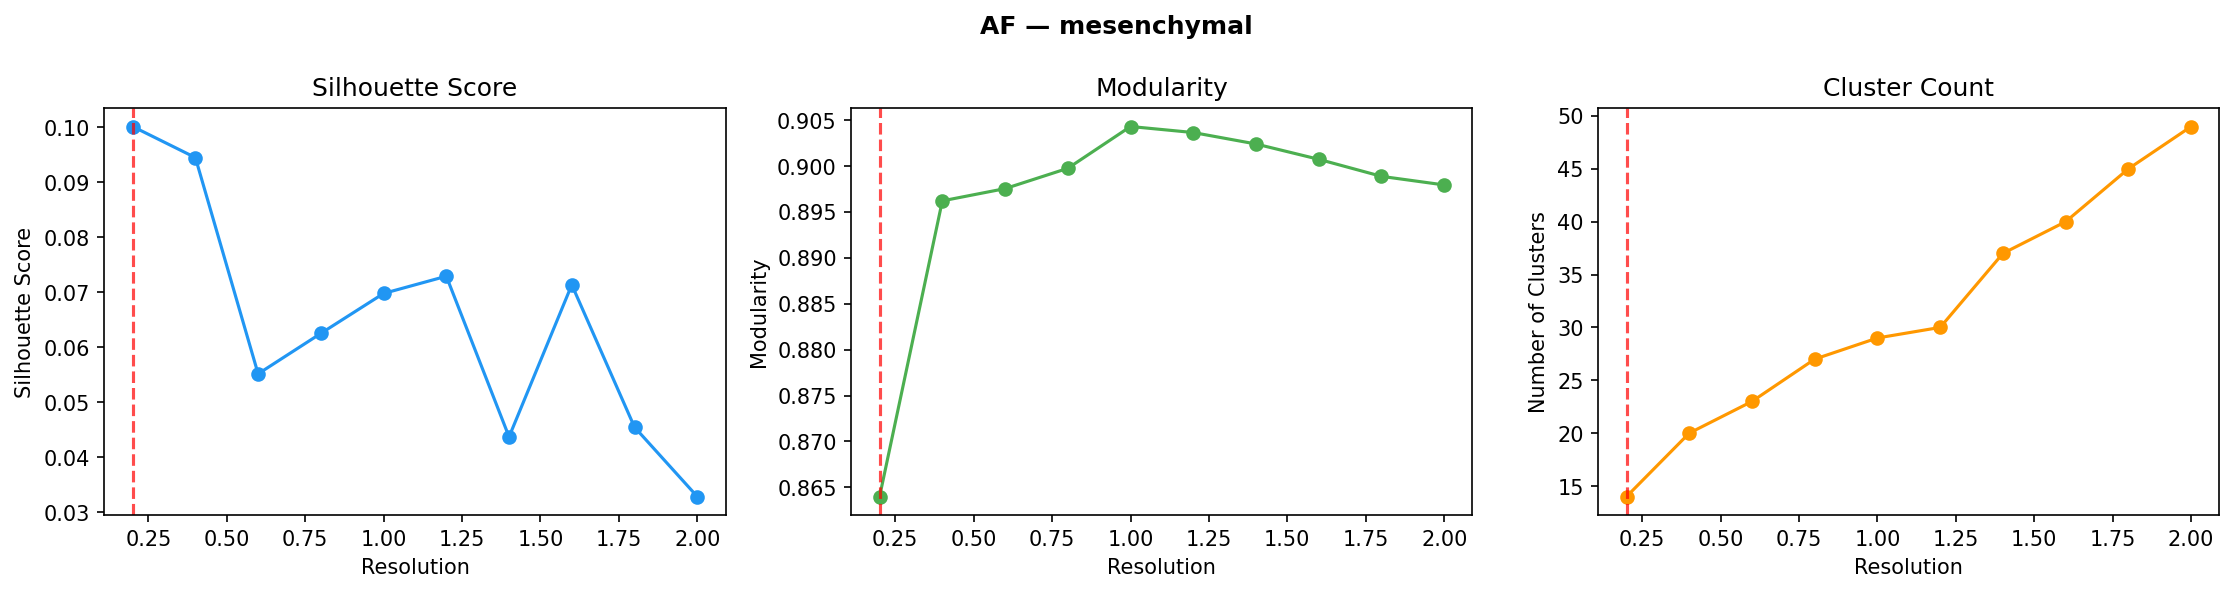

### Cep Mesenchymal

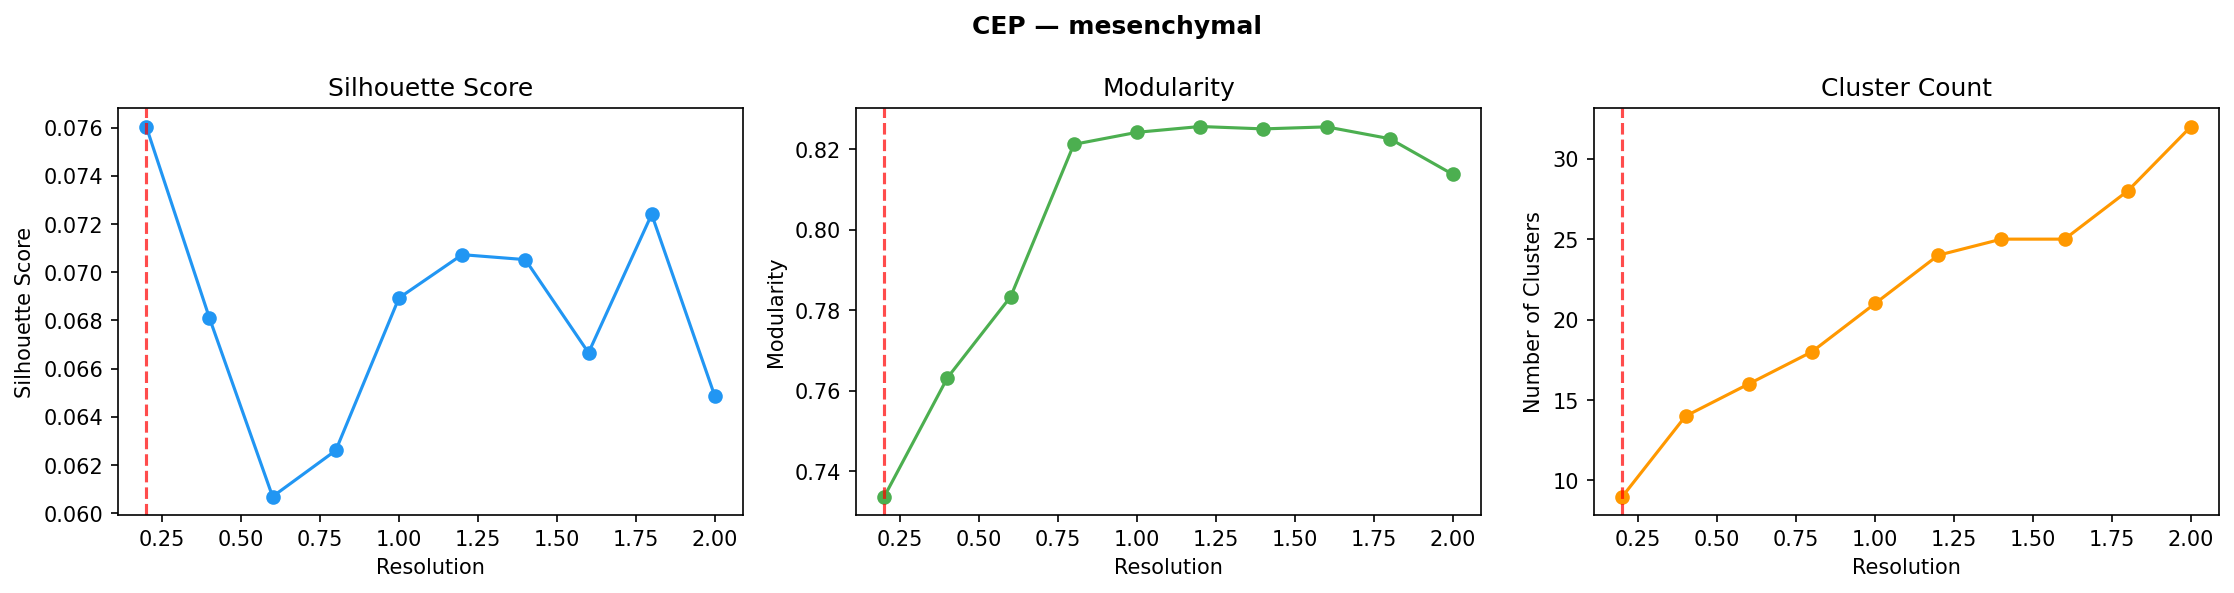

### Np Mesenchymal

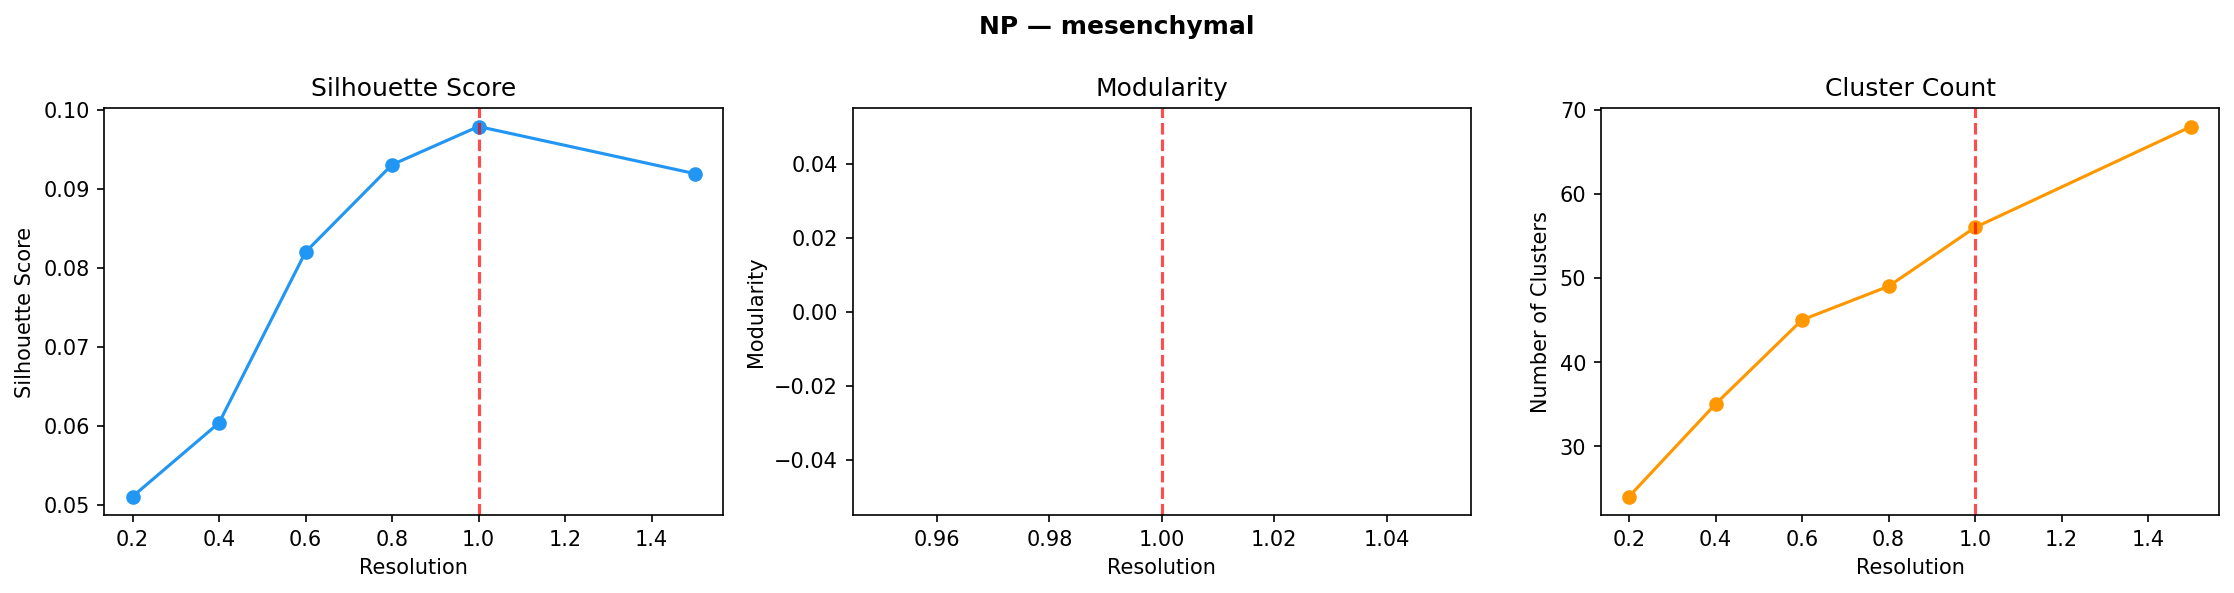

### Np Non Mesenchymal

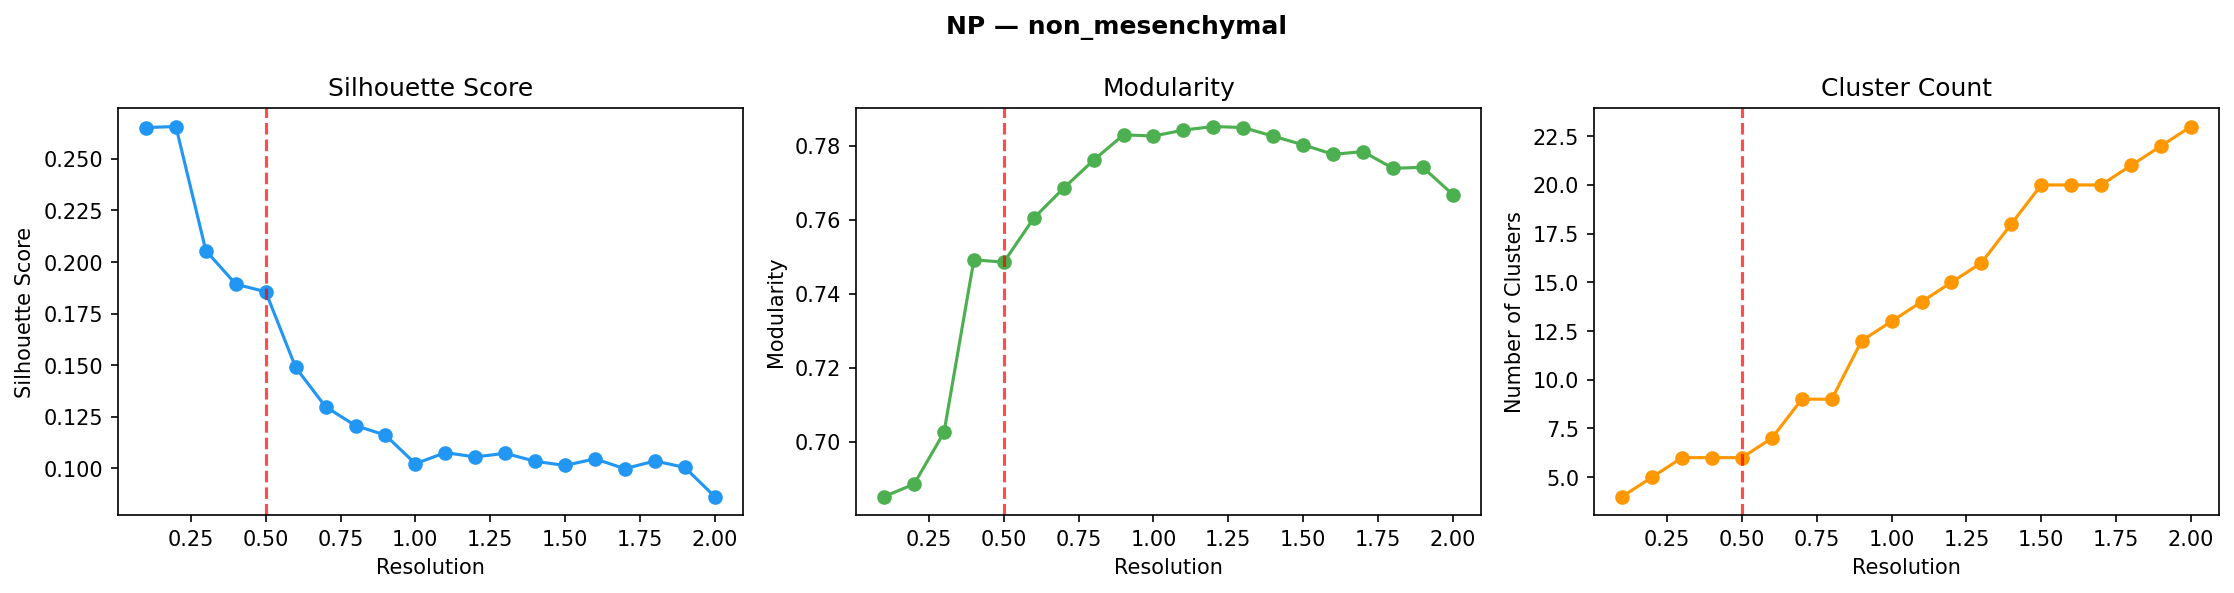

### All Cells Mesenchymal

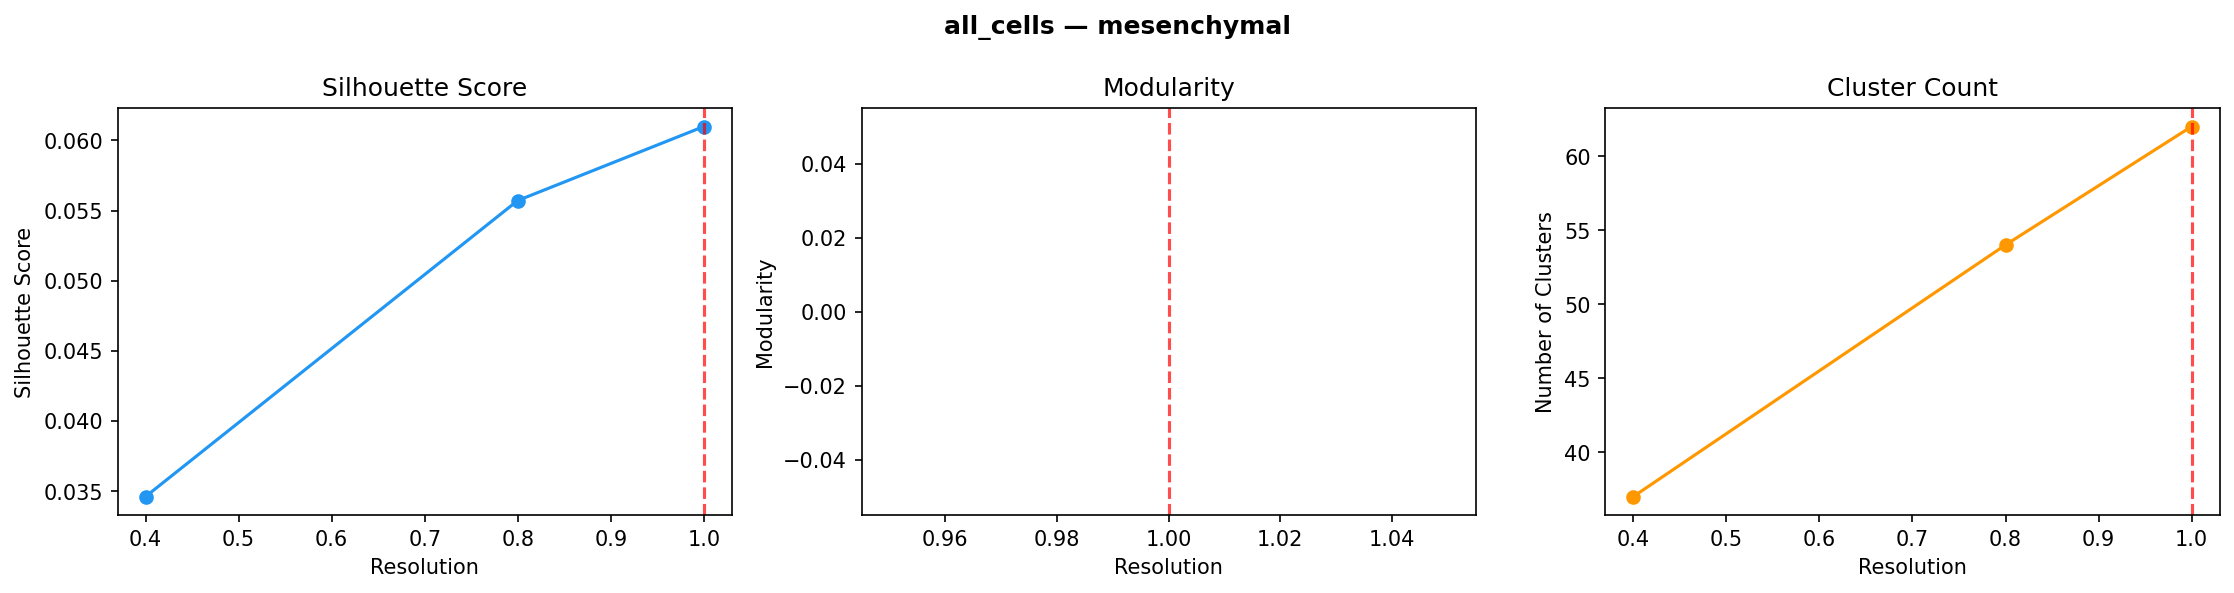

### All Cells Non Mesenchymal

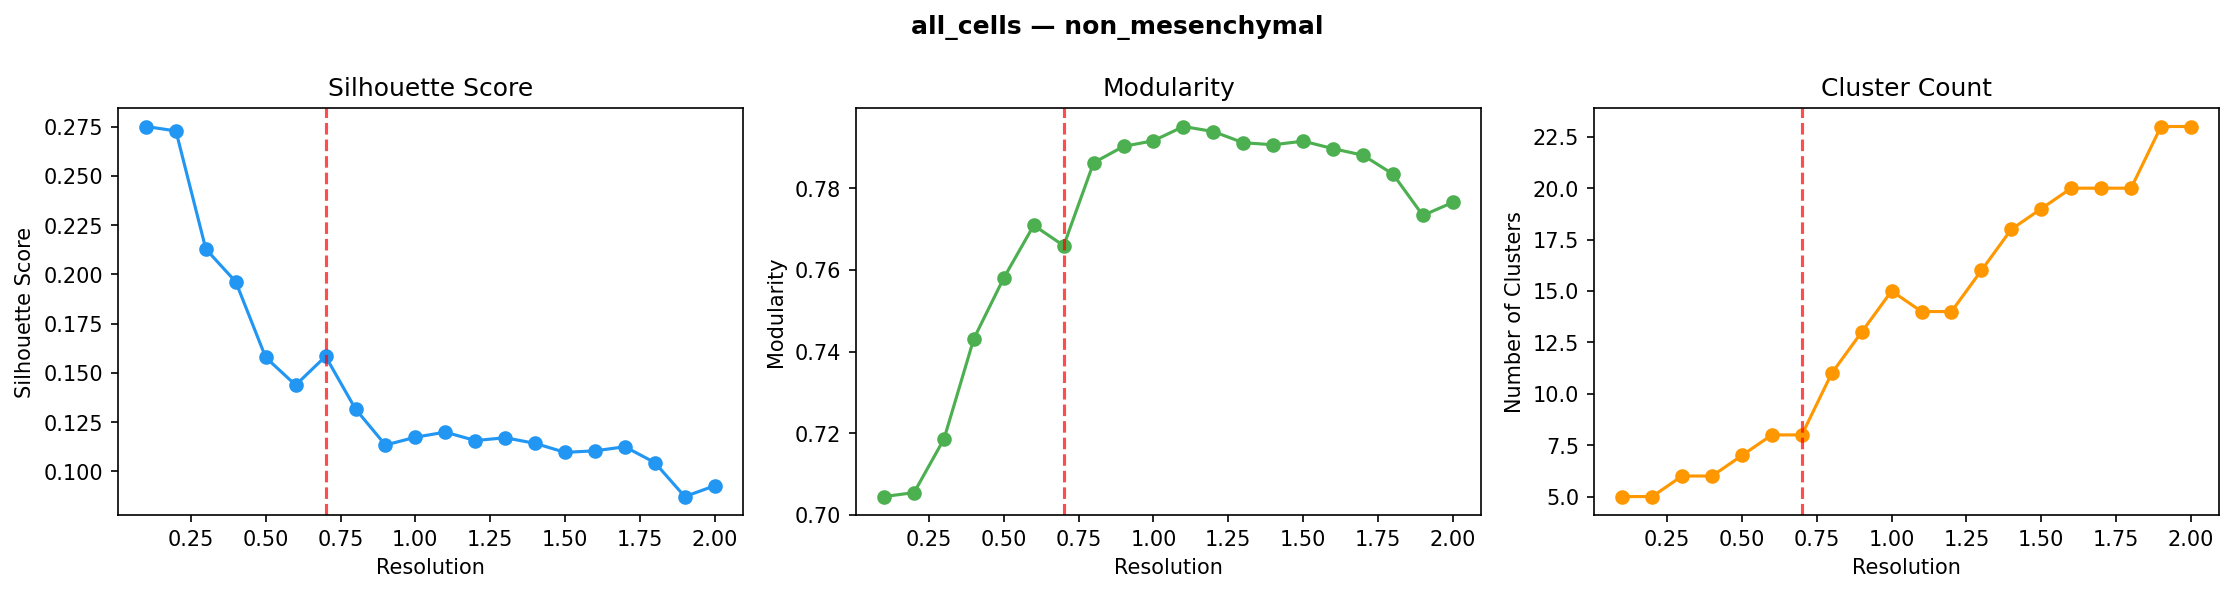

### All Cells Unassigned

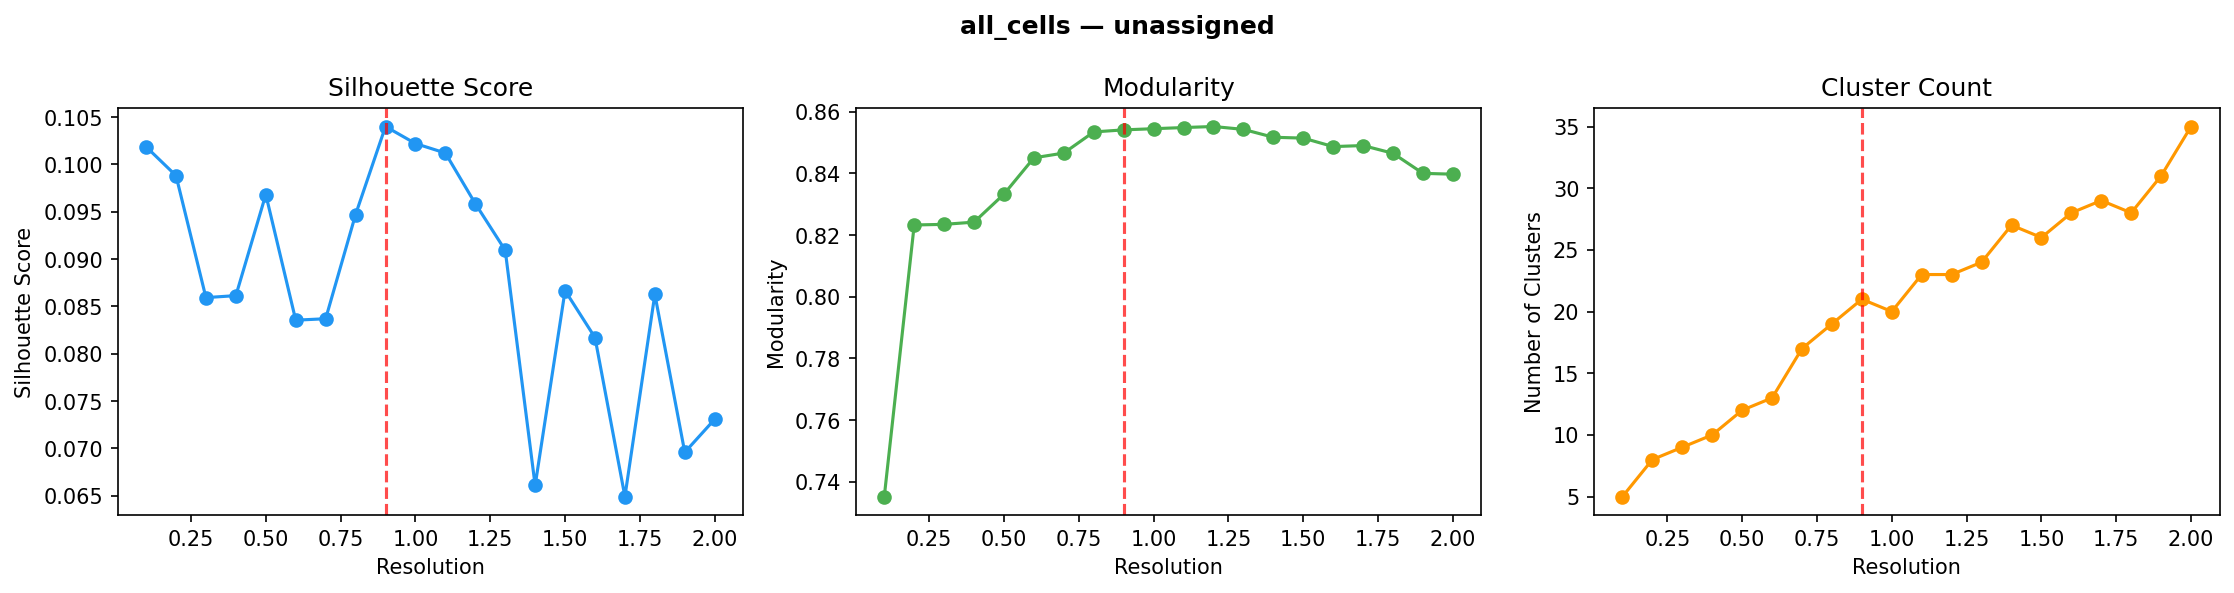

In [2]:
# Display resolution optimization plots for each compartment/tier
opt_plots = sorted(OPT_DIR.glob('*_optimization.png'))
print(f'Resolution optimization plots: {len(opt_plots)}')

for fpath in opt_plots:
    label = fpath.stem.replace('_optimization', '').replace('_', ' ').title()
    display(Markdown(f'### {label}'))
    display(Image(filename=str(fpath), width=800))

## Resolution Scan Tables

Selected resolutions and metrics for each compartment/tier combination.

In [3]:
# Display resolution scan tables
res_tables = sorted(OPT_DIR.glob('*_resolutions.tsv'))
print(f'Resolution scan tables: {len(res_tables)}')

for fpath in res_tables:
    label = fpath.stem.replace('_resolutions', '').replace('_', ' ').title()
    df = pd.read_csv(fpath, sep='\t')
    display(Markdown(f'### {label}'))
    display(df.style.set_caption(f'{label} — Resolution Scan Results'))

Resolution scan tables: 7


### Af Mesenchymal

,resolution,n_clusters,silhouette,modularity
0,0.200000,14,0.100173,0.863992
1,0.400000,20,0.094515,0.896211
2,0.600000,23,0.055157,0.897543
3,0.800000,27,0.062521,0.899755
4,1.000000,29,0.069790,0.904311
5,1.200000,30,0.072923,0.903654
6,1.400000,37,0.043695,0.902405
7,1.600000,40,0.071364,0.900737
8,1.800000,45,0.045450,0.898880
9,2.000000,49,0.032820,0.897944


### Cep Mesenchymal

,resolution,n_clusters,silhouette,modularity
0,0.200000,9,0.076048,0.733721
1,0.400000,14,0.068107,0.763244
2,0.600000,16,0.060693,0.783362
3,0.800000,18,0.062607,0.821202
4,1.000000,21,0.068933,0.824196
5,1.200000,24,0.070731,0.825638
6,1.400000,25,0.070525,0.825043
7,1.600000,25,0.066660,0.825548
8,1.800000,28,0.072404,0.822611
9,2.000000,32,0.064855,0.813736


...

,resolution,n_clusters,silhouette,modularity
0,0.400000,37,0.034604,nan
1,0.800000,54,0.055716,nan
2,1.000000,62,0.060994,nan


### All Cells Non Mesenchymal

,resolution,n_clusters,silhouette,modularity
0,0.100000,5,0.275037,0.704496
1,0.200000,5,0.272796,0.705471
2,0.300000,6,0.212839,0.718589
3,0.400000,6,0.196213,0.743207
4,0.500000,7,0.157844,0.758075
5,0.600000,8,0.143814,0.770940
6,0.700000,8,0.158398,0.765956
7,0.800000,11,0.131665,0.786268
8,0.900000,13,0.113383,0.790269
9,1.000000,15,0.117348,0.791657


### All Cells Unassigned

,resolution,n_clusters,silhouette,modularity
0,0.100000,5,0.101860,0.735234
1,0.200000,8,0.098810,0.823272
2,0.300000,9,0.085933,0.823476
3,0.400000,10,0.086143,0.824197
4,0.500000,12,0.096820,0.833274
5,0.600000,13,0.083550,0.845040
6,0.700000,17,0.083702,0.846593
7,0.800000,19,0.094707,0.853436
8,0.900000,21,0.104001,0.854103
9,1.000000,20,0.102202,0.854481


## Cluster UMAP per Compartment

UMAP colored by Leiden cluster labels for each compartment. This shows the
spatial distribution of clusters on the scANVI-integrated embedding.

### NP — 62 Leiden Clusters

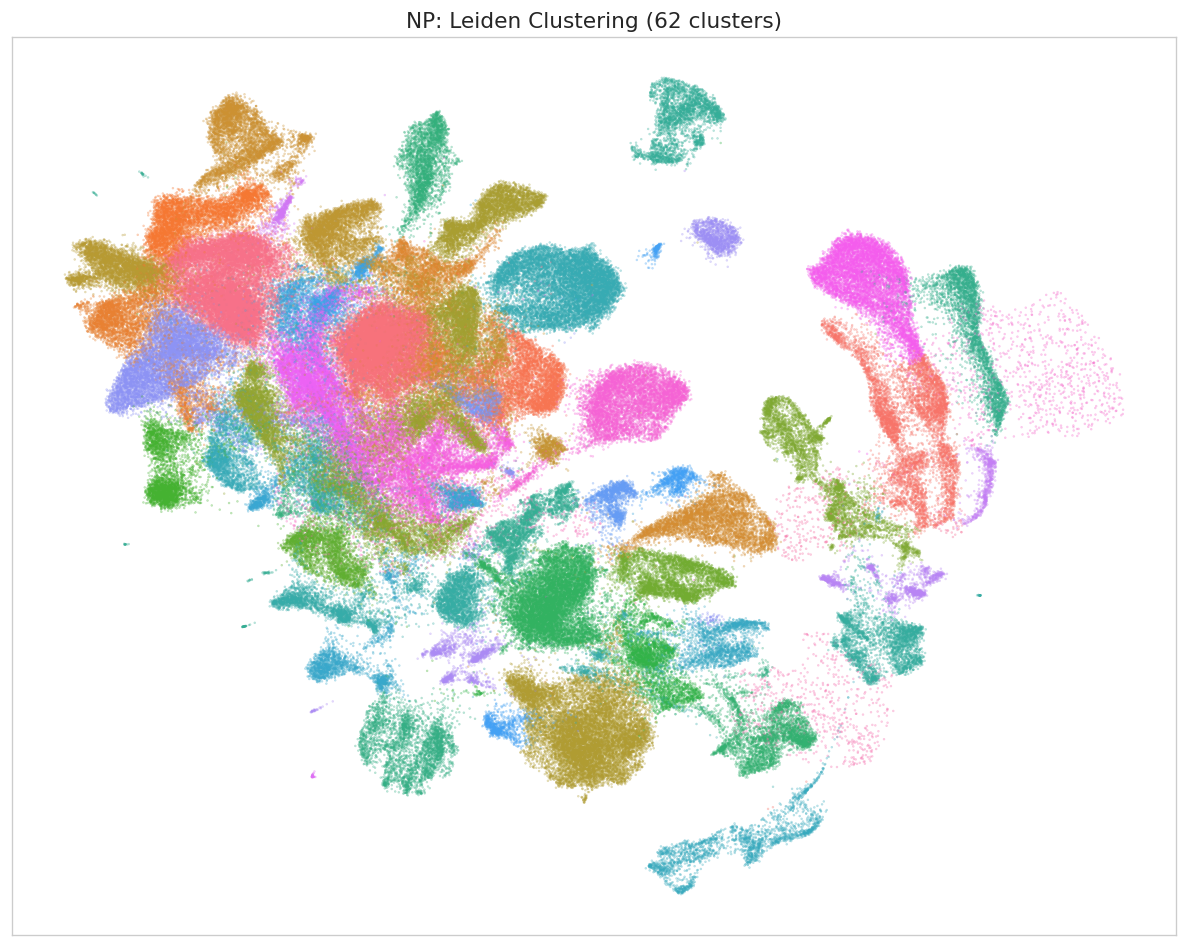

### AF — 14 Leiden Clusters

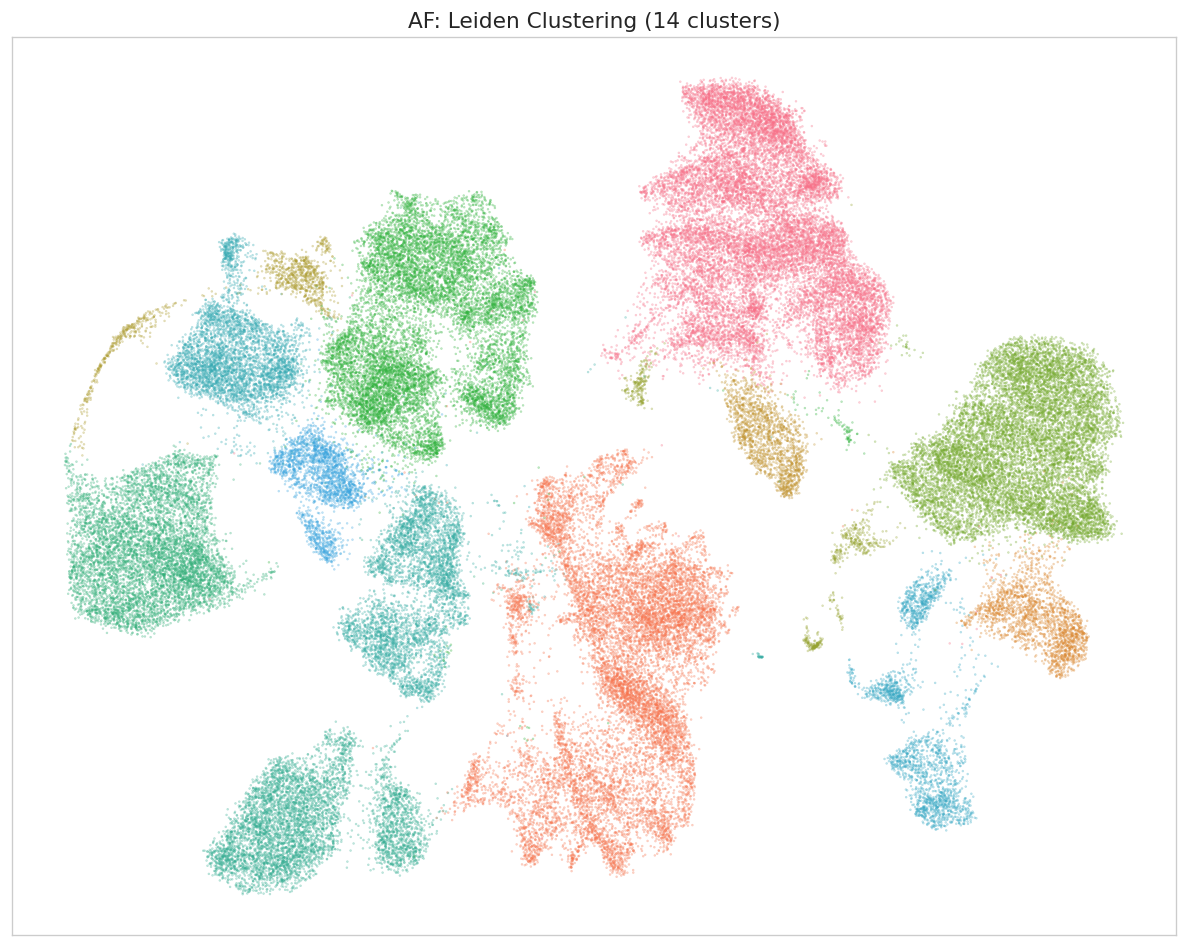

### CEP — 9 Leiden Clusters

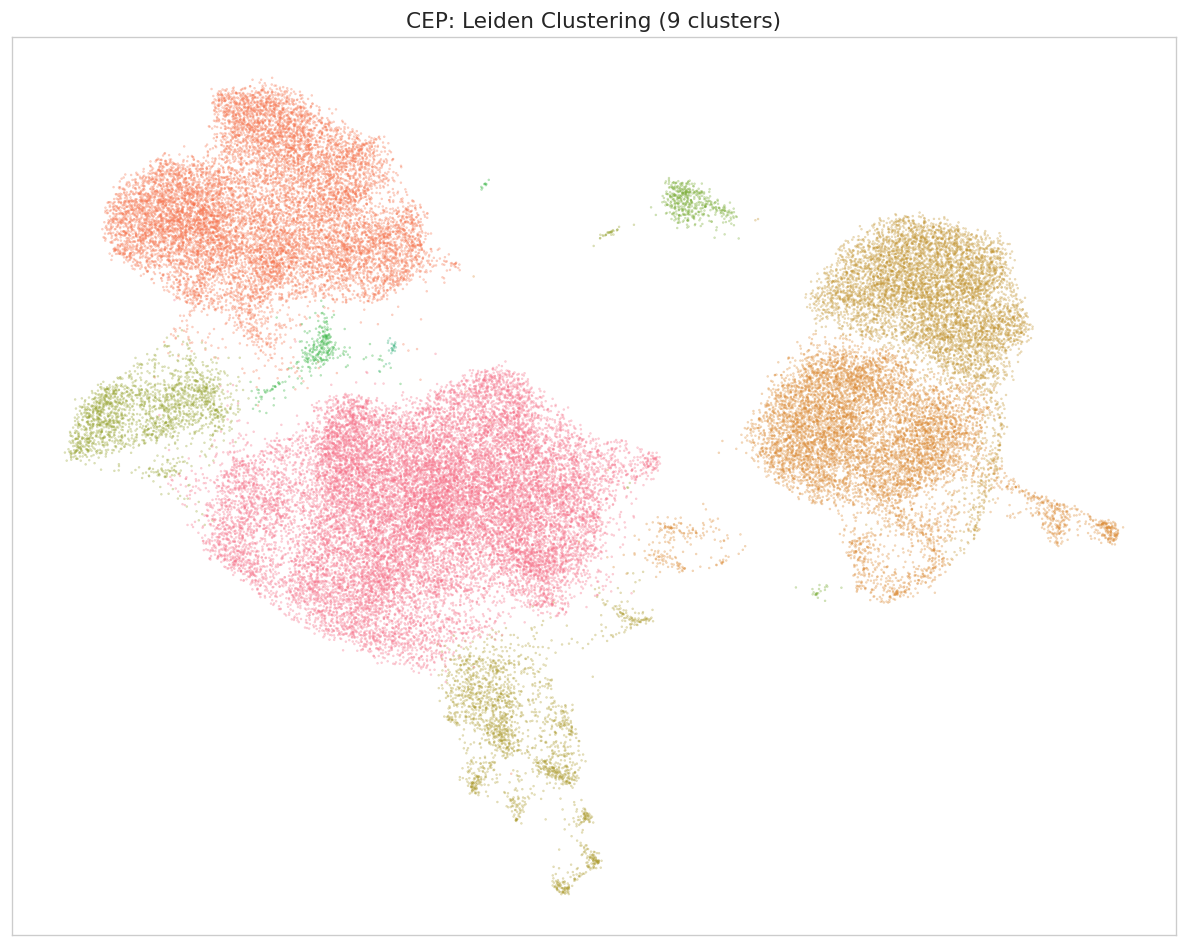

In [4]:
# Plot UMAP colored by Leiden cluster for each compartment (lightweight load)
for comp_name, comp_path in [('NP', COMPARTMENTS['NP']),
                              ('AF', COMPARTMENTS['AF']),
                              ('CEP', COMPARTMENTS['CEP'])]:
    if not comp_path.exists():
        print(f'{comp_name}: file not found')
        continue

    adata = sc.read_h5ad(comp_path, backed='r')
    obs_df = adata.obs.to_memory() if hasattr(adata.obs, 'to_memory') else adata.obs.copy()
    umap = adata.obsm['X_umap'][:] if 'X_umap' in adata.obsm else None
    n_clusters = obs_df['leiden'].nunique() if 'leiden' in obs_df.columns else 0
    adata.file.close()

    if umap is None or 'leiden' not in obs_df.columns:
        print(f'{comp_name}: missing UMAP or leiden column')
        continue

    display(Markdown(f'### {comp_name} — {n_clusters} Leiden Clusters'))

    # Plot
    unique_clusters = sorted(obs_df['leiden'].unique(), key=lambda x: int(x) if str(x).isdigit() else x)
    n_colors = max(len(unique_clusters), 20)
    palette = dict(zip(unique_clusters,
                       sns.color_palette('husl', n_colors)))

    fig, ax = plt.subplots(figsize=(10, 8))
    idx = np.random.RandomState(42).permutation(len(umap))
    labels = obs_df['leiden'].values
    colors = [palette.get(labels[i], '#cccccc') for i in idx]
    ax.scatter(umap[idx, 0], umap[idx, 1], c=colors, s=0.2, alpha=0.4, rasterized=True)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'{comp_name}: Leiden Clustering ({n_clusters} clusters)', fontsize=13)

    fig.tight_layout()
    fig.savefig(FIG_DIR / f'notebook_06_{comp_name}_leiden_umap.png', dpi=150, bbox_inches='tight')
    plt.show()

    del obs_df, umap

## Cluster Size Distributions

Bar chart of cluster sizes for each compartment, showing how cells are
distributed across clusters.

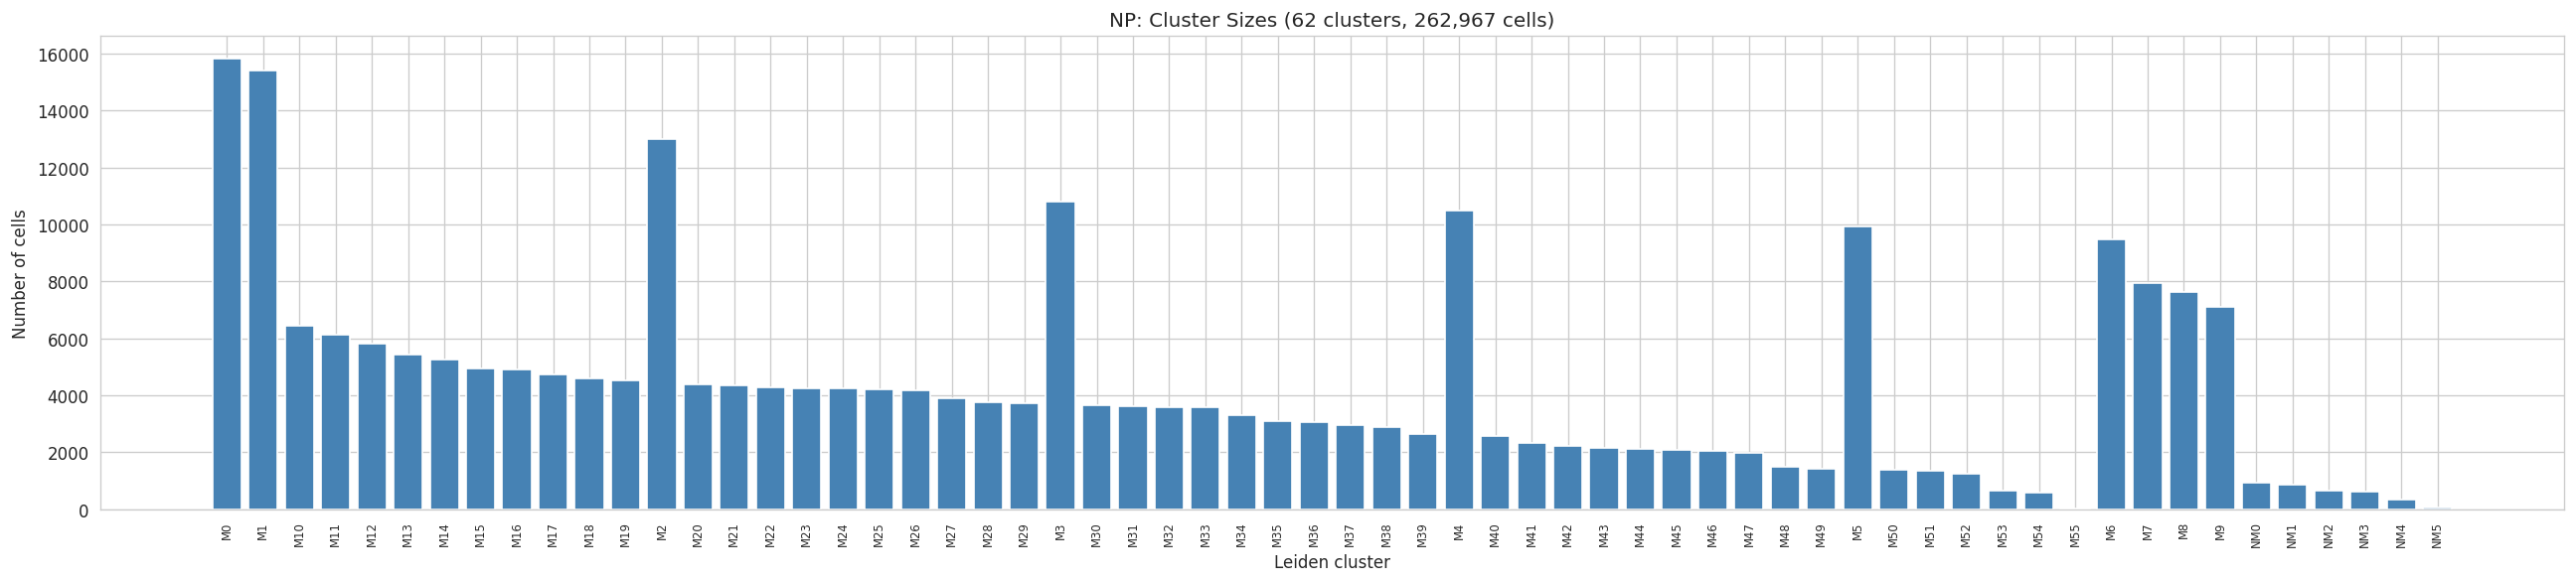

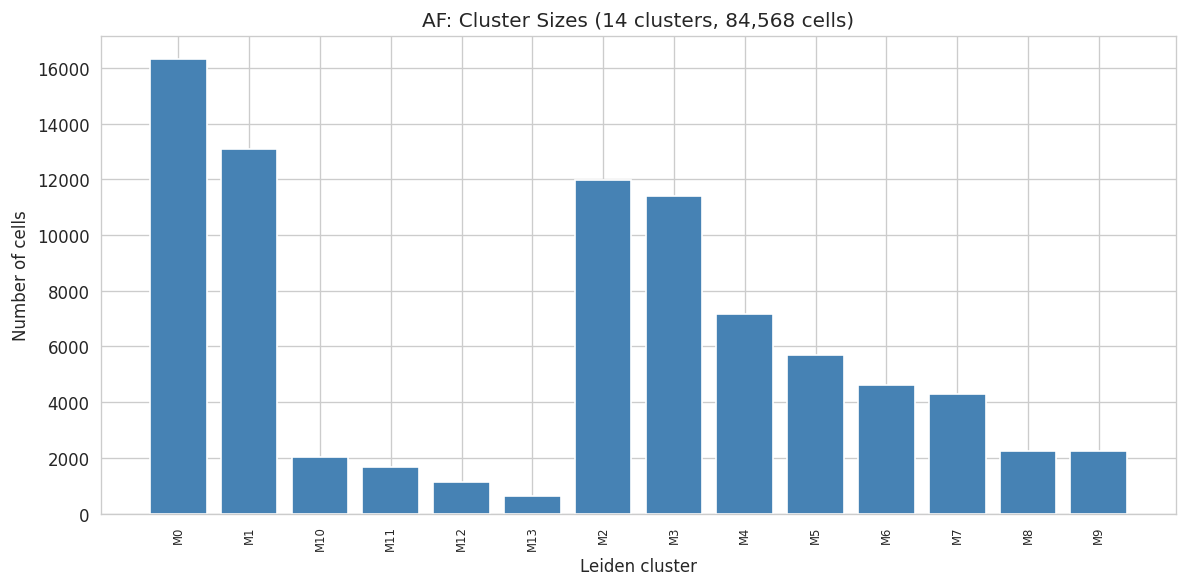

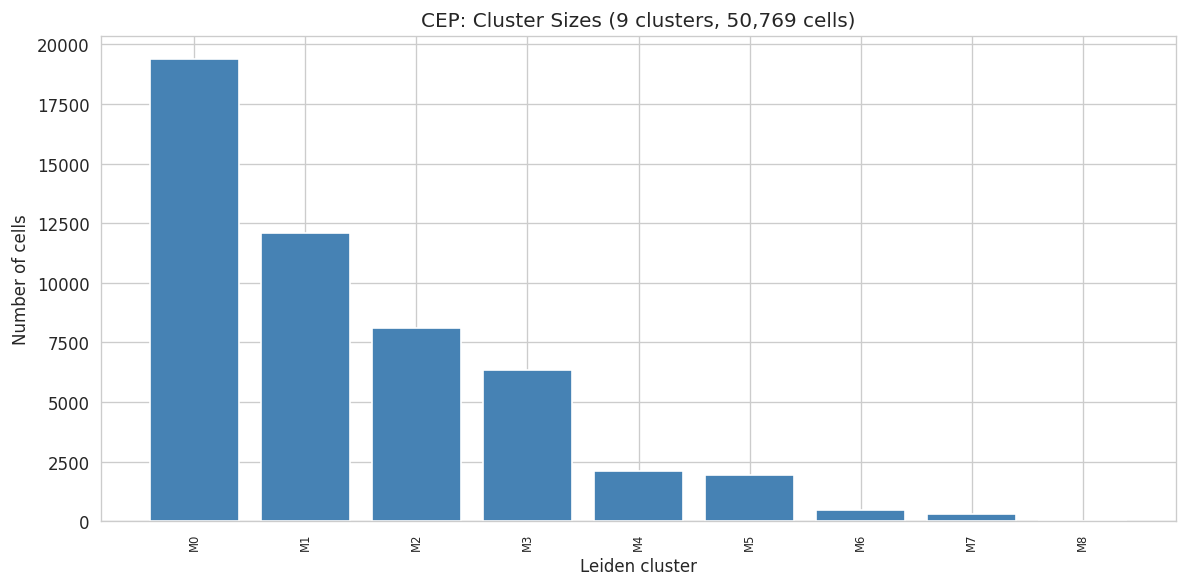

In [5]:
# Cluster size bar charts per compartment
for comp_name, comp_path in [('NP', COMPARTMENTS['NP']),
                              ('AF', COMPARTMENTS['AF']),
                              ('CEP', COMPARTMENTS['CEP'])]:
    if not comp_path.exists():
        continue
    adata = sc.read_h5ad(comp_path, backed='r')
    obs_df = adata.obs.to_memory() if hasattr(adata.obs, 'to_memory') else adata.obs.copy()
    adata.file.close()

    if 'leiden' not in obs_df.columns:
        continue

    counts = obs_df['leiden'].value_counts().sort_index(
        key=lambda x: x.astype(int) if x.str.isdigit().all() else x)

    fig, ax = plt.subplots(figsize=(max(10, len(counts) * 0.35), 5))
    ax.bar(range(len(counts)), counts.values, color='steelblue', edgecolor='white')
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=90, fontsize=7)
    ax.set_ylabel('Number of cells')
    ax.set_xlabel('Leiden cluster')
    ax.set_title(f'{comp_name}: Cluster Sizes ({len(counts)} clusters, {len(obs_df):,} cells)')
    fig.tight_layout()
    plt.show()

    del obs_df

## Status — Module 06 Complete (v4)

### Summary
- Leiden clustering on scANVI latent space with automated resolution optimization
- Separate clustering for mesenchymal and non-mesenchymal tiers
- NP: 62 clusters, AF: 14 clusters, CEP: 9 clusters, all_cells: 70 clusters
- Resolution optimization balances cluster granularity with biological signal
- Cluster labels stored in `leiden` column; tier-specific in `leiden_mesenchymal`, `leiden_non_mesenchymal`
- Annotation of clusters into cell types follows in Module 07